<a href="https://colab.research.google.com/github/ilaydacepniogluu-sys/AkademiQ_DataScience/blob/main/AkademiQ_HAFTA5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo -q

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo  # fetch_ucirepo: UCI dan veri setini ID ile birlikte almak demektir.

from sklearn.model_selection import train_test_split #Veri setini eğitim (train) ve test (test) olarak ikiye ayırır.
from sklearn.compose import ColumnTransformer #Veri setindeki farklı sütunlara farklı ön işleme yöntemleri uygulamayı sağlar.
from sklearn.preprocessing import OneHotEncoder #Kategorik verileri makine öğrenmesi algoritmalarının kullanabileceği sayısal forma dönüştürür.
from sklearn.impute import SimpleImputer #Veri setindeki eksik değerleri ortalama, medyan veya en sık görülen değer gibi yöntemlerle doldurur
from sklearn.pipeline import Pipeline #Veri ön işleme ve makine öğrenmesi adımlarını tek bir işlem zinciri halinde çalıştırmayı sağlar.
from sklearn.tree import DecisionTreeClassifier, plot_tree #Oluşturulan karar ağacını (sınıflandırma modeli) grafik olarak görselleştirir. plot_tree: karar ağacını(ağacın kendisini) görebilmek içindi.
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score #classification_report: Modelin doğruluk (accuracy), precision, recall ve F1-score gibi performans metriklerini raporlar.
#confusion_matrix: Modelin doğru ve yanlış tahmin sayılarını gösteren hata matrisi oluşturur.
#roc_auc_score: Modelin sınıfları ayırt etme başarısını ROC eğrisi altındaki alan (AUC) değeri ile ölçer.

In [ ]:
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features.copy() #bağımsız değişkenler yani müşteriye ait olan özellikler
y = bank_marketing.data.targets.copy()  #hedef değişkenler


display(X.head())
display(y.head())


print(" X boyutları:", X.shape)
print(" y boyutları:", y.shape)

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


,y
0,no
1,no
2,no
3,no
4,no


 X boyutları: (45211, 16)
 y boyutları: (45211, 1)


# Hedef Değişken Hazırlama

In [ ]:
target_col = y.columns[0]

y = y[target_col].map({
    "yes":1,
    "no":0
})

print(y.value_counts())
print(y.value_counts(normalize=True))

y
0    39922
1     5289
Name: count, dtype: int64
y
0    0.883015
1    0.116985
Name: proportion, dtype: float64


 # Sütun Tiplerini Ayırma


In [ ]:
numeric_features = X.select_dtypes(include={"int64", "float64"}).columns.tolist()

categorical_features = X.select_dtypes(include={"object", "category"}).columns.tolist()

print("Sayısal Sütunlar:")
print(numeric_features)

print("\nKategorik Sütunlar:")
print(categorical_features)

Sayısal Sütunlar:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

Kategorik Sütunlar:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


# Train Test Bölme

In [ ]:
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (36168, 16)
Test: (9043, 16)


 # Ön İşleme Pipeline'ı

In [ ]:
numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

categorical_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[("num", numeric_pipeline, numeric_features), ("cat", categorical_pipeline, categorical_features)])

SimpleImputer(strategy="median"): Eksik sayısal değerleri sütunun medyanı ile doldurur.
categorical_pipeline: Kategorik sütunlar için işlem hattı oluşturur.

SimpleImputer(strategy="most_frequent"): Eksik kategorik değerleri en sık görülen değerle doldurur.

OneHotEncoder(): Kategorik verileri sayısal forma dönüştürür.

handle_unknown="ignore": Daha önce görülmemiş kategoriler gelirse hata vermeden yok sayar.

ColumnTransformer: Sayısal ve kategorik sütunlara farklı işlemler uygular.

("num", ...): Sayısal sütunlara numeric_pipeline uygulanır.

("cat", ...): Kategorik sütunlara categorical_pipeline uygulanır.

# Decision Tree Model Kurma

In [ ]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split =50,
    class_weight= "balanced",
    random_state=42
)
model_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", decision_tree_model)])

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'balance',
                                                   'day_of_week', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_split=50,
                                        random_state=42))])

# Tahmnin ve Olasılık Üretme

In [ ]:
y_pred = model_pipeline.predict(X_test) #y lerde tahmninleme çıkartıcaz

y_proba = model_pipeline.predict_proba(X_test)[:,1]  #her bir sınıf için olasılık üretmek

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85      7985
           1       0.32      0.84      0.46      1058

    accuracy                           0.77      9043
   macro avg       0.65      0.80      0.66      9043
weighted avg       0.90      0.77      0.81      9043

ROC-AUC: 0.8704412100666066


predict() → Sınıf tahmini üretir.

predict_proba() → Olasılık üretir.

classification_report() → Precision, Recall, F1 hesaplar.

roc_auc_score() → Modelin genel ayırma gücünü ölçer.

# Karar Ağacı

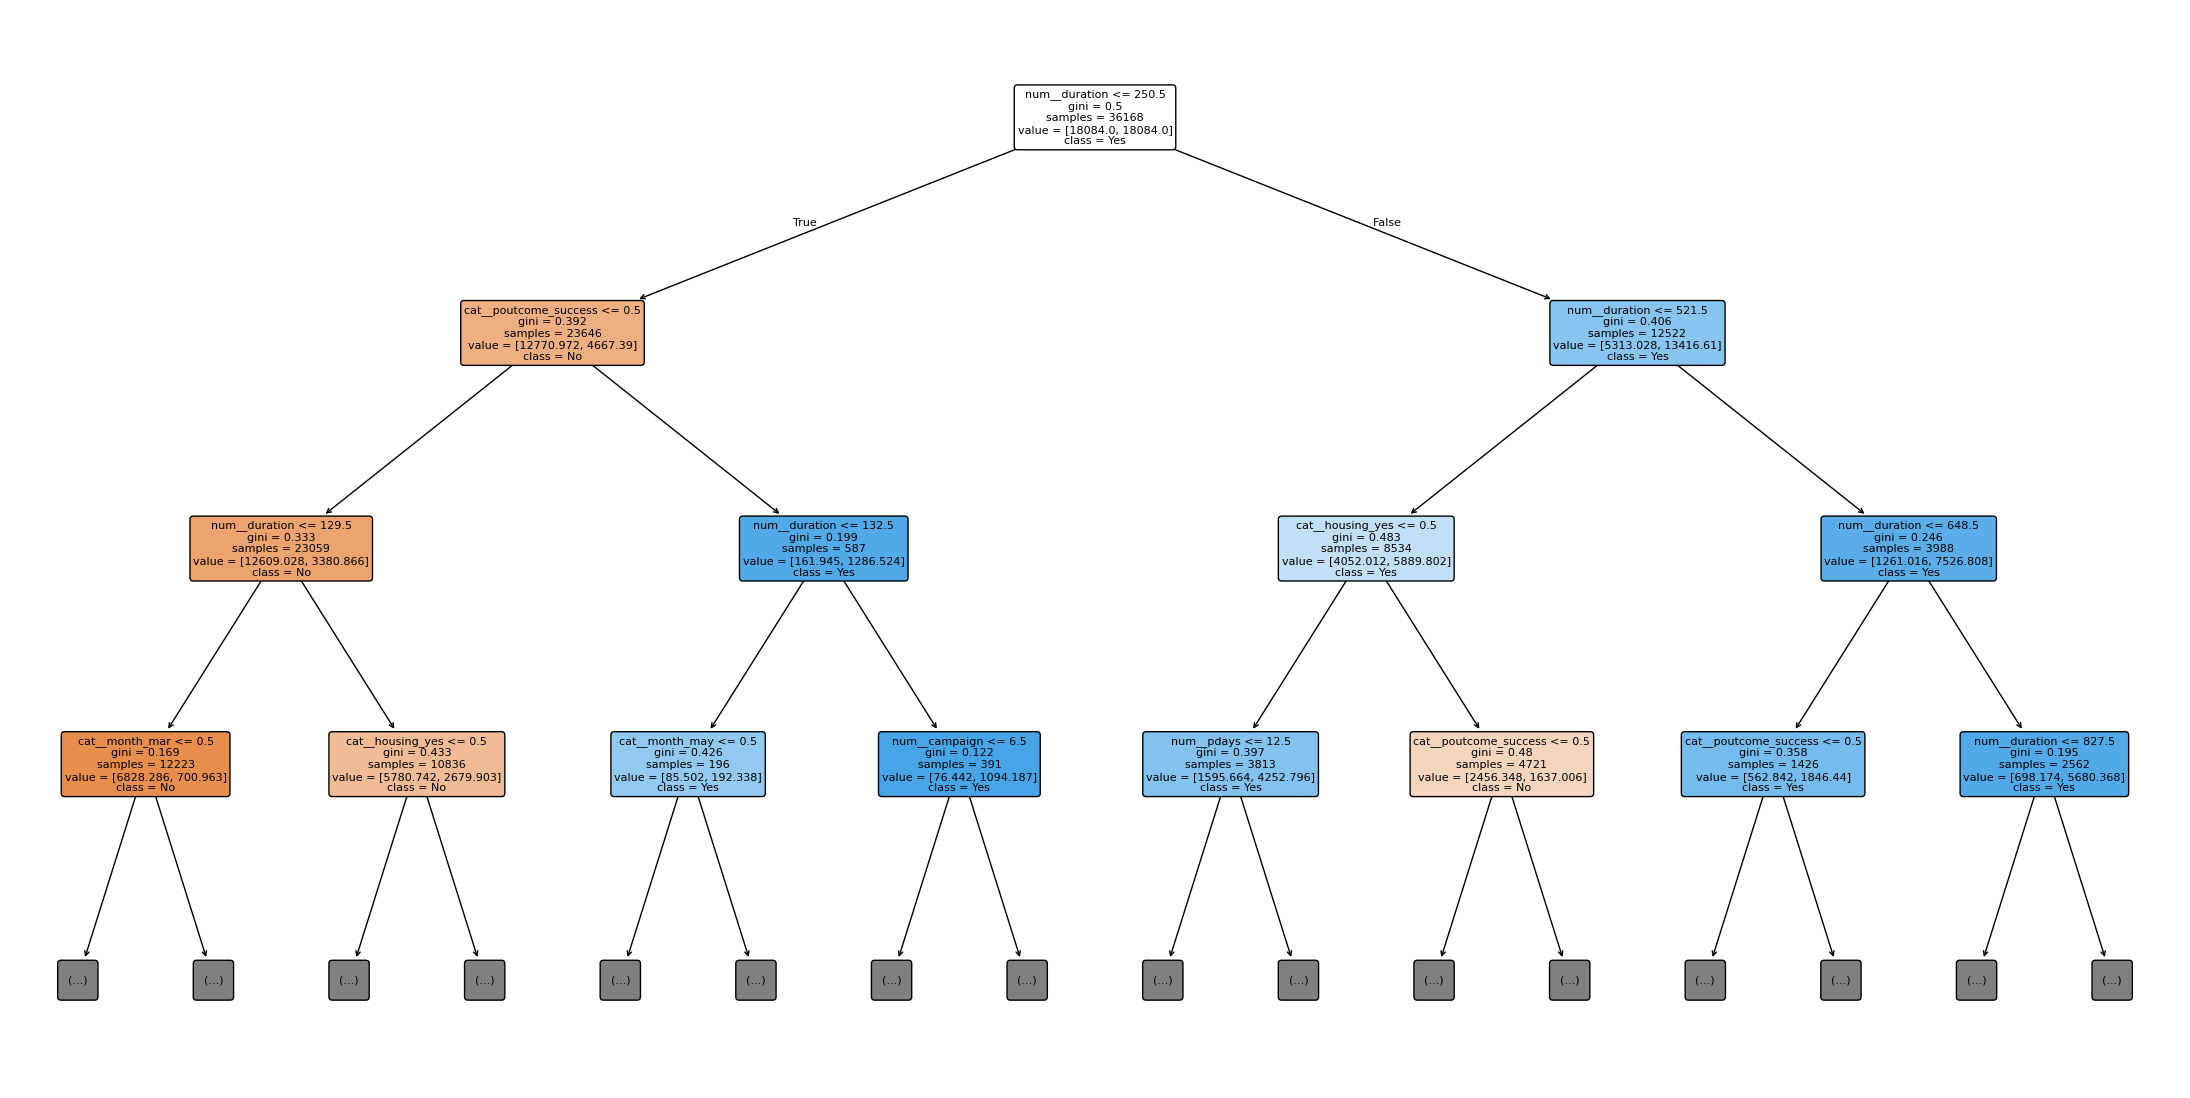

In [ ]:
trained_tree = model_pipeline.named_steps["model"] #Pipeline'ın içindeki "model" adındaki adımı alıp trained_tree değişkenine atıyor.

feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out() #Modelin kullandığı sütun isimlerini alıyor.

plt.figure(figsize=(28,14))

plot_tree(trained_tree,
          feature_names= feature_names,
          class_names=["No", "Yes"],
          filled= True,
          rounded= True,
          fontsize=8,
          max_depth=3)
plt.show()

trained_tree = model_pipeline.named_steps["model"] → Pipeline içindeki eğitilmiş karar ağacı modelini alır.

feature_names=model_pipeline.named_steps["preprocessor"].get_feature_names_out() → Ön işleme sonrası oluşan tüm özellik (sütun) isimlerini alır.


plt.figure(figsize=(28,14)) → 28 birim genişliğinde ve 14 birim yüksekliğinde bir grafik alanı oluşturur.


plot_tree(...) → Karar ağacını görselleştirmek için kullanılan fonksiyondur.


trained_tree → Çizilecek karar ağacı modelini belirtir.
feature_names=feature_names → Karar ağacındaki düğümlerde özellik isimlerinin görünmesini sağlar.


class_names=["No", "Yes"] → Hedef değişkenin sınıf isimlerini "No" ve "Yes" olarak gösterir.
filled=True → Düğümlerin baskın sınıfa göre renklendirilmesini sağlar.


rounded=True → Düğüm kutularının köşelerini yuvarlatır.

fontsize=8 → Ağaç üzerindeki yazıların boyutunu 8 olarak ayarlar.

max_depth=3 → Ağacın yalnızca ilk 3 seviyesinin görüntülenmesini sağlar.

plt.show() → Oluşturulan karar ağacı grafiğini ekranda gösterir.
